In [3]:
print("HoangHa")

HoangHa


# Coding an LLM architecture

In [4]:

from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.0
torch version: 2.10.0+cpu
tiktoken version: 0.12.0


In [5]:
GPT_CONFIG_124M={
    'vocab_size':50257, #Vocabulary size
    'context_length':1024,
    'emb_dim':768, 
    'n_heads':12, 
    'n_layers':12, 
    'drop_rate':0.1,
    'qkv_bias': False
}

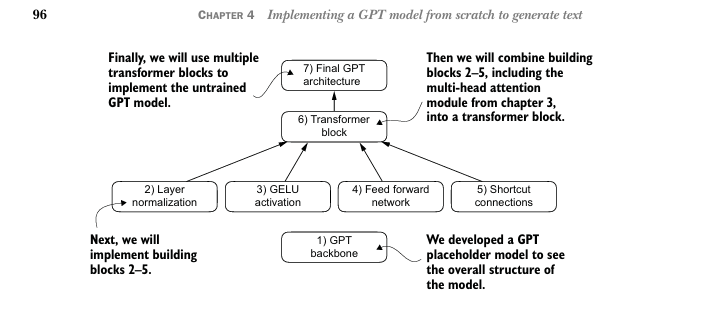

## Create DummyGPTModel 

In [6]:
import torch 
import torch.nn as nn 
class DummyGPTModel(nn.Module): 
    def __init__(self, cfg): 
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'],cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg['n_layers'])]
        )
        self.final_norm = DummyLayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(
            cfg['emb_dim'],cfg['vocab_size'],bias = False
        )

    def forward(self,in_idx): 
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x= tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x= self.trf_blocks(x)
        x= self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module): 
    def __init__(self, cfg): 
        super().__init__()

    def forward(self,x): 
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape,eps=1e-5): 
        super().__init__()

    def forward(self,x): 
        return x 

In [7]:
import tiktoken 
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [8]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## Normalizing activations with layer normalization

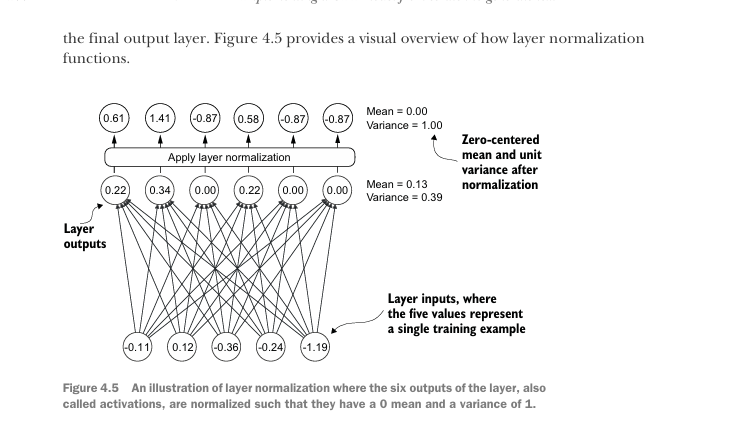

In [9]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
layer = nn.Sequential(nn.Linear(5,6),nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [10]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


### Apply layer normalization

In [11]:
out_norm = (out-mean)/torch.sqrt(var)
mean = out_norm.mean(dim=-1,keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [12]:
class LayerNorm(nn.Module): 
    def __init__(self, emb_dim): 
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim)) # xem chieu nao quan trong 
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self,x): 
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [13]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


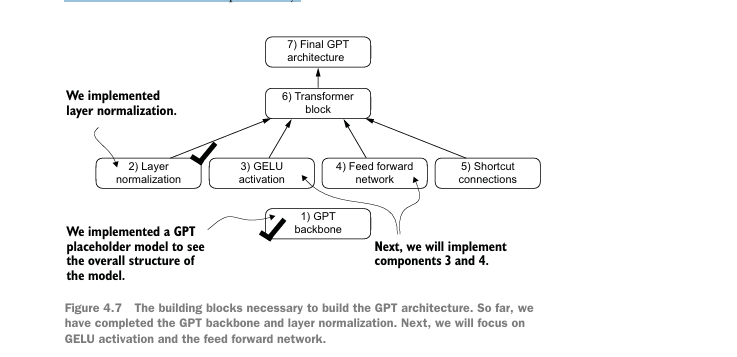

## Implementing a FNN with GELU activations

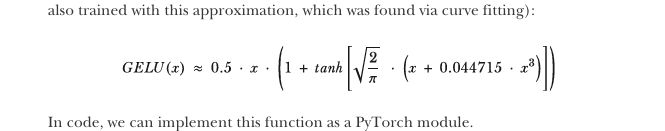


In [14]:
class GELU(nn.Module): 
    def __init_(self): 
        super().__init__()
    def forward(self,x): 
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))


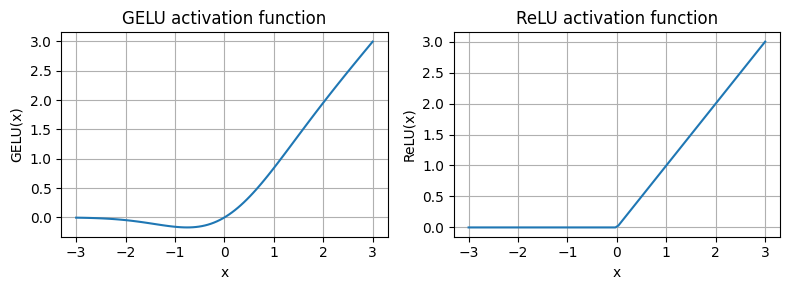

In [15]:
import matplotlib.pyplot as plt

gelu,relu = GELU(),nn.ReLU()
x=torch.linspace(-3,3,100)
y_gelu,y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
class FeedForward(nn.Module): 
    def __init__(self, cfg): 
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]), 
            GELU(),
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self,x):
        return self.layers(x)

In [17]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


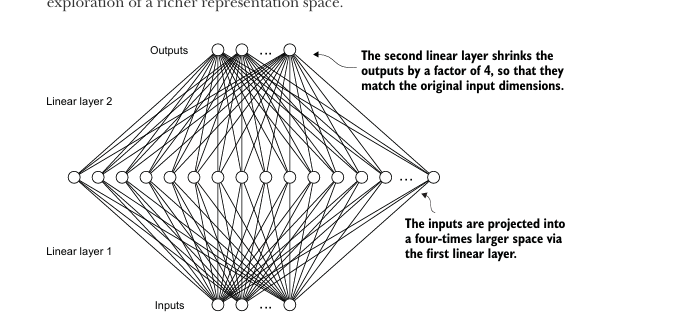

## Adding shortcut connection

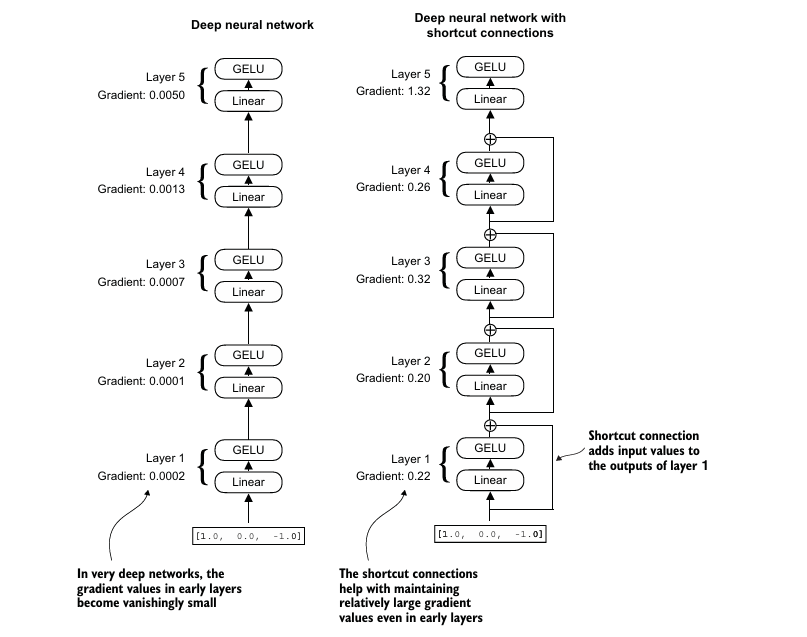

In [18]:
class ExampleDeepNeuralNetwork(nn.Module): 
    def __init__(self, layer_sizes , use_shortcut): 
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList(
            [nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]), GELU())]
        )

    def forward(self, x): 
        for layer in self.layers: 
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape: 
                x = x + layer_output
            else: 
                x = layer_output
        return x



In [19]:
layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In [20]:
def print_gradients(model,x): 
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()
    for name,param in model.named_parameters(): 
        if 'weight' in name: 
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [21]:
print_gradients(model_without_shortcut, sample_input)


layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


The output of the print_gradients function shows, the gradients become smaller
as we progress from the last layer (layers.4) to the first layer (layers.0), which is
a phenomenon called the vanishing gradient problem.

In [22]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169798612594604
layers.1.0.weight has gradient mean of 0.20694111287593842
layers.2.0.weight has gradient mean of 0.3289700150489807
layers.3.0.weight has gradient mean of 0.26657330989837646
layers.4.0.weight has gradient mean of 1.3258544206619263


# Connecting attention and linear layers

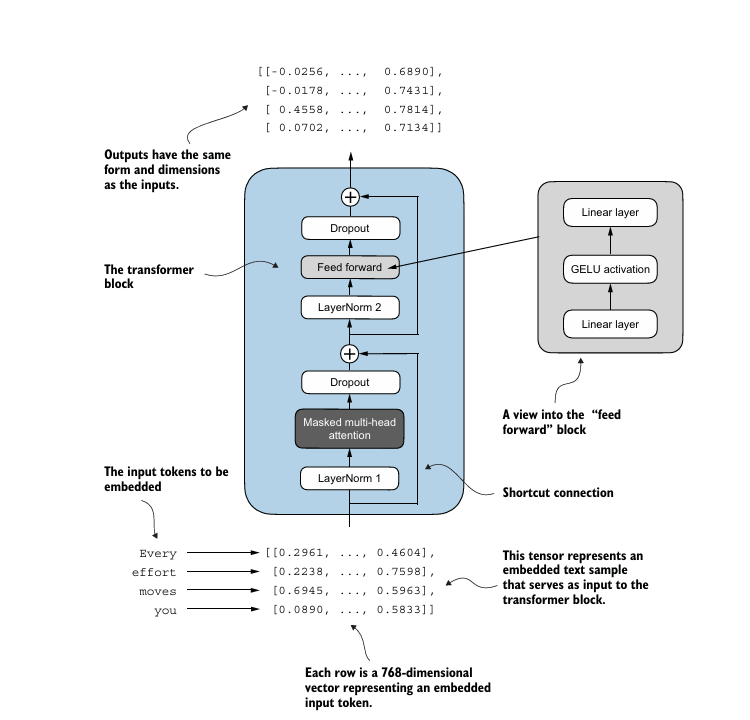

In [23]:
class MultiHeadAttention(nn.Module): 
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out//num_heads
        self.W_query= nn.Linear(d_in,d_out,bias = qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out) # học cách kết hợp các gó nhìn
        self.dropout=nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),diagonal=1)
        )

    def forward(self,x): 
        b,num_tokens,d_in = x.shape 
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        keys = keys.view(b,num_tokens,self.num_heads,self.head_dim) # view ddeer chia thanh nhieu head (2,4,256) --> (2,4,8,32)
        values = values.view(b,num_tokens,self.num_heads,self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim )    
        keys = keys.transpose(1,2) #(batch, head, tokens, dim)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        attn_scores = queries @ keys.transpose(2,3) # (batch,head,dịm,tokens)
        mask_bool = self.mask.bool() [:num_tokens,:num_tokens]

        attn_scores.masked_fill_(mask_bool,-torch.inf)
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5,dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec =  (attn_weights @ values).transpose(1, 2) 
        
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)   
        return context_vec
        

In [24]:

class TransformerBlock(nn.Module): 
    def __init__(self, cfg): 
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"], 
            d_out = cfg["emb_dim"], 
            context_length = cfg["context_length"], 
            num_heads = cfg["n_heads"],
            dropout = cfg["drop_rate"], 
            qkv_bias = cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2=LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])


    def forward(self, x): 
        shortcut = x
        x=self.norm1(x)
        x=self.att(x)
        x=self.drop_shortcut(x)
        x=x+shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x+shortcut
        return x

In [25]:
torch.manual_seed(123)
x = torch.rand(2,4,768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


# Build GPT Model

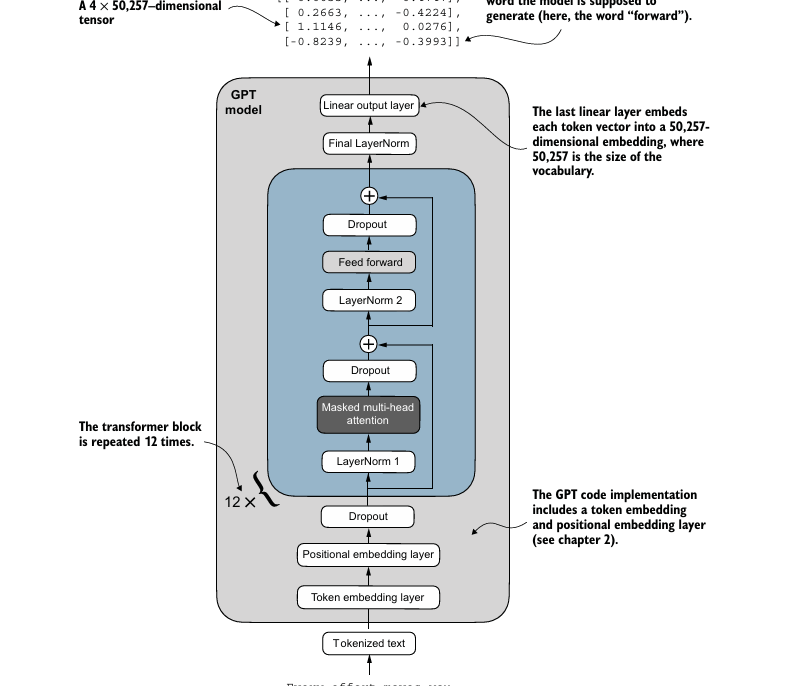

In [35]:
class GPTModel(nn.Module): 
    def __init__(self, cfg): 
        super().__init__()
        self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks=nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias = False
        )

    def forward(self,in_idx): 
        batch_size,seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len,device=in_idx.device)
        )
        x=tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x=self.trf_blocks(x)
        x= self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [36]:
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


## Predict next token and have mask 

In [37]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out=model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


## check total numbers of parameter

In [38]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")


Total number of parameters: 163,009,536


In [39]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [40]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


In [41]:
total_size_bytes = total_params * 4      
total_size_mb = total_size_bytes / (1024 * 1024)    
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


# Generating text

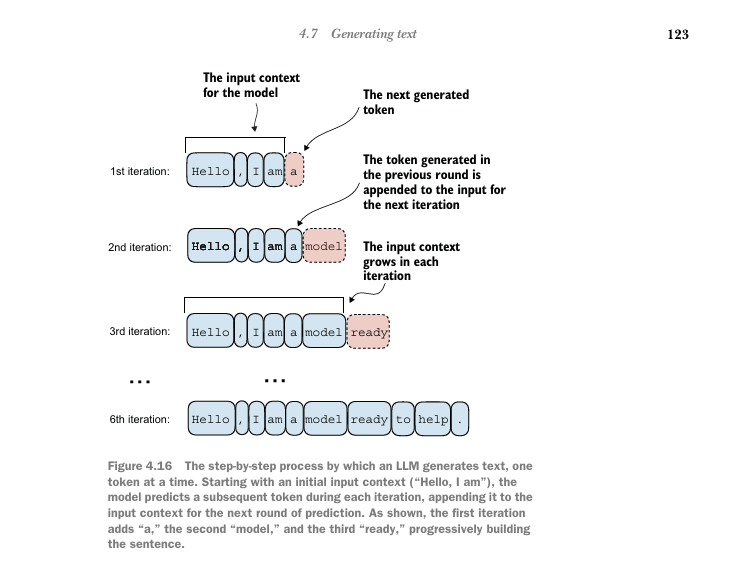

In [42]:
def generate_text_simple(model, idx, max_new_tokens,context_size): 
    for _ in range(max_new_tokens): 
        idx_cond = idx[:,-context_size:]
        with torch.no_grad(): 
            logits = model(idx_cond)

        logits = logits[:,-1,:] # chir laays token cuoi 
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim = True)
        idx = torch.cat((idx,idx_next),dim=-1)

    return idx

In [43]:
start_context = "Hello,I am"
encode = tokenizer.encode(start_context)
print("encode: ",encode)
encoded_tensor = torch.tensor(encode).unsqueeze(0)
print("encoded_tensor.shape: ",encoded_tensor.shape)

encode:  [15496, 11, 40, 716]
encoded_tensor.shape:  torch.Size([1, 4])


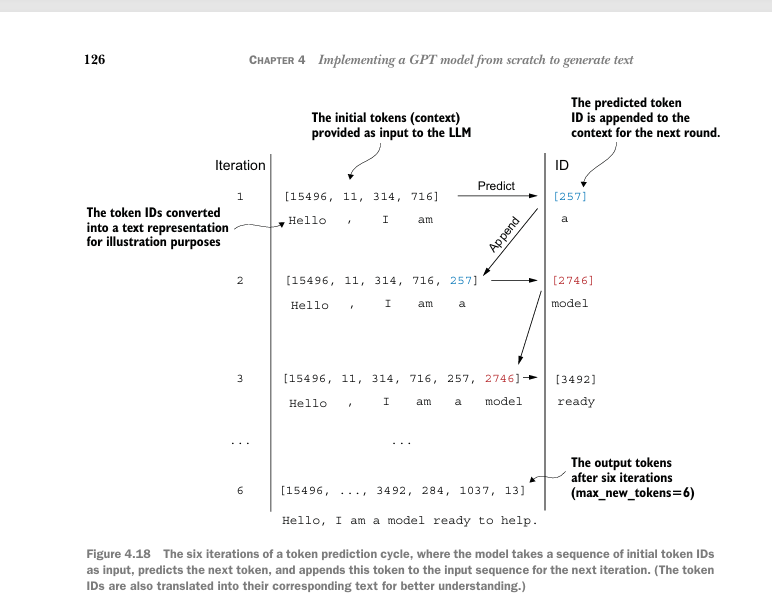

In [46]:
model.eval()
out = generate_text_simple(
    model = model, 
    idx = encoded_tensor, 
    max_new_tokens= 6 , 
    context_size = GPT_CONFIG_124M["context_length"]
)
print("output: ",out)
print("output length: ",len(out[0]))

output:  tensor([[15496,    11,    40,   716, 27018,  7283, 46275, 11472, 21692, 43530]])
output length:  10


In [48]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello,I am Feature IT snowball shocked merits neocons
